In [2]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

df = pd.read_csv('../data collections/melb_data.csv')

In [3]:
df.sample(5)

df=df.dropna(axis =1)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Landsize       13580 non-null  float64
 13  Lattitude      13580 non-null  float64
 14  Longtitude     13580 non-null  float64
 15  Regionname     13580 non-null  str    
 16  Propertycount  13580 non-null  float64
dtypes: float64(9), int64(1), str(7)
memory usage: 1.8 MB
None


In [4]:
features= ['Rooms', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Landsize', 'Propertycount']

X= df[features]
y=df.Price

rf= RandomForestRegressor(random_state=0, n_jobs=2)


X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=0, test_size=0.2, train_size=0.8)

In [5]:
params = {
    'n_estimators': [ 5, 10, 25],
    'max_depth': [None, 4, 8, 12],
    'min_samples_leaf': [1, 2, 4, 6, 10],
    'max_features':['sqrt', 'log2']
    
    }

grid_search= GridSearchCV(estimator=rf, param_grid=params, cv=5, verbose=2, scoring='neg_mean_absolute_error', n_jobs=4)

grid_search.fit(X_train, y_train)

print('Bästa parameterna: ', grid_search.best_params_)
print('Bästa score: ', grid_search.best_score_)

best_model= grid_search.best_estimator_
predictions = best_model.predict(X_test)


Fitting 5 folds for each of 120 candidates, totalling 600 fits
Bästa parameterna:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 25}
Bästa score:  -198242.6446989788


In [6]:
y.describe()

count    1.358000e+04
mean     1.075684e+06
std      6.393107e+05
min      8.500000e+04
25%      6.500000e+05
50%      9.030000e+05
75%      1.330000e+06
max      9.000000e+06
Name: Price, dtype: float64

In [7]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

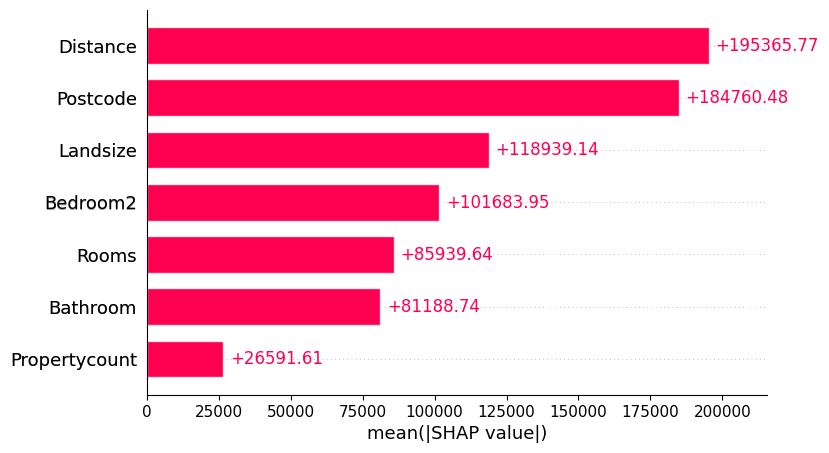

In [8]:
shap.plots.bar(shap_values)

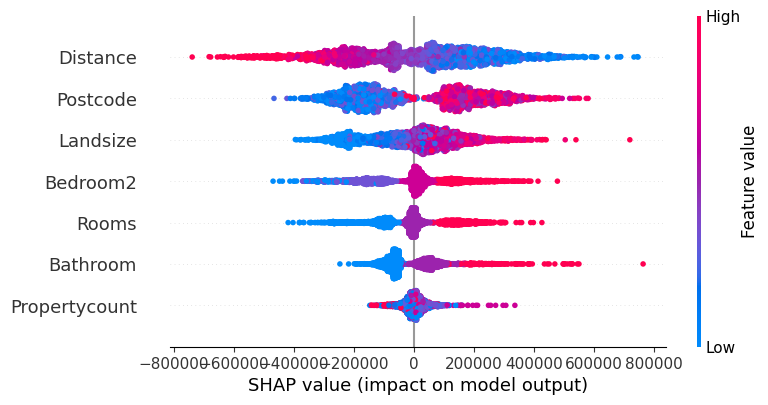

In [9]:
shap.plots.beeswarm(shap_values)